In [230]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap

In [80]:
# suggested values
alpha_val = 0.9
beta_val = 0.2
small_gamma_val = 0.1
lambda_0 = 1
lambda_1 = 5

n = 10
big_T = 100

Plan:
* make transition matrix
* make emission matrix
* make pi?
* simulate (research how)

In [81]:

# C_t = 0: serial stimuli 0
# C_t = 1: serial stimuli 1
# C_t = 2: parallel both stimuli 0 & 1

def create_transition_matrix(gamma: float, beta: float):
    Gamma = np.array([[1 - gamma,  0,          gamma], 
                      [0,          1 - gamma,  gamma], 
                      [beta/2,     beta/2,     1 - beta]])
    return Gamma

## Emission - conditional $Z_{t,i}$
Since our model has multiple layers, we don't directly have an emission matrix from $C_t$ to $X_{t,i}$. Instead we need to go through $Z_{t,i}$ up to $C_t$, which is given as the conditional:
$$
P(Z_{t,i} = 1 | C_t = c) = \begin{cases}
1 - \alpha & \text{if } c = 0 \\
\alpha & \text{if } c = 1 \\
0.5 & \text{if } c = 2
\end{cases}
$$


In [82]:
def p_z_given_c(alpha, c: int): # z_{t,i} = 1 | C_t = c
    if c == 0:
        return 1 - alpha
    elif c == 1:
        return alpha
    elif c == 2:
        return 0.5
    else:
        raise ValueError("Error with input, only c = 0, c = 1 or c = 2 accepted.")

In [83]:
# p_z_given_c(alpha=alpha_val, c=2)

In [84]:
test_matrix = create_transition_matrix(gamma=small_gamma_val, beta=beta_val)
print(test_matrix)

[[0.9 0.  0.1]
 [0.  0.9 0.1]
 [0.1 0.1 0.8]]


## Random Walk for $n = 10$, and $T = 100$

In [85]:

# * suggested values
# alpha_val = 0.9
# beta_val = 0.2
# small_gamma_val = 0.1
# lambda_0 = 1
# lambda_1 = 5

# n = 10
# big_T = 100

def simulate_c(gamma, beta, T):
    Gamma = create_transition_matrix(gamma=gamma, beta=beta)
    C = np.empty(T, dtype=int) # empty matrix to hold simulated values
    C[0] = 2 # first entry is always 2
    
    c_states = np.array([0,1,2], dtype=int) # possible states C_t can take on
    
    for t in range(1, T):
        # depending on the value the previous C had, we do a choice for where to go next given the distribution
        # so if we start at 2, our C[T-1] = 2, and so we'd access p=Gamma[2], and sample a random choice of those (giving us [0,1,2] as possible outcomes)
        # and select that value as the next C[T].
        C[t] = np.random.choice(a=c_states, p=Gamma[C[t-1]]) 
        
    return C
        

In [89]:
# C = simulate_c(gamma=small_gamma_val, beta=beta_val, T=big_T)
# C

In [87]:
def simulate_z(C, alpha, n):
    T = len(C) # to ensure we don't give a new T which would break our previous (shapes)
    Z = np.empty(shape=(T, n), dtype=int) # before we only had one C per time slice, but now we have a Z per neuron, of which there are n, so we need a matrix instead of an array
    for t in range(0, T):
        z_prob = p_z_given_c(alpha=alpha, c=C[t]) # all Z's have the same C (share parent), so we only get a single C per row in matri x
        Z[t] = np.random.binomial(n=1, p=z_prob, size=n) # and now we do a random draw per z, that is for each row we do n random bernoulli samples (z \in \brc{0, 1})
    return Z

In [88]:
def simulate_x(Z, lam0, lam1):
    T = len(Z)
    n = len(Z[0])
    X = np.empty(shape=(T,n), dtype=int)
    for t in range(0, T):
        lambdas = np.where(Z[t] == 0, lam0, lam1)
        X[t] = np.random.poisson(lam=lambdas, size=n)
    return X

### Simulation run

In [105]:
C = simulate_c(gamma=small_gamma_val, beta=beta_val, T=big_T)
Z = simulate_z(C=C, alpha=alpha_val, n=n)
X = simulate_x(Z=Z, lam0=lambda_0, lam1=lambda_1)

print(C.shape)
print(Z.shape)
print(X)

(100,)
(100, 10)
[[ 2  6  5  6  0  0  3  3  5  0]
 [ 3  0  8  3  0  2  4 10  3  1]
 [ 4  5  6  0  4  0  1  3  2  4]
 [ 4  1  4  6  1  3  2  6  6  0]
 [ 1  4  3  4  7  4  3  0  2  4]
 [ 9  2  1  5  9  3  5  4  1  2]
 [ 5  4  3  4  6 11  5  4  5  0]
 [ 3  0  1  7  3  0  1  1  1  4]
 [ 5 11  6  3  4  5  6  1  5  3]
 [ 3  3  0  5  1  0  3  4  5  2]
 [ 1  4  4  3  2  7  5  7  7  4]
 [ 3  4  7  2  5  6  1  5  3  6]
 [ 2  4  2  1  3  0  0  0  1  8]
 [ 1  1  2  2  3  2  3  1  1  2]
 [ 1  1  2  1  1  1  0  7  1  1]
 [ 0  0  0  4  1  4  0  1  4  1]
 [ 1  1  1  0  1  0  1  1  1  0]
 [ 0  0  2  2  1  1  0  1  0  7]
 [ 3  1  2  0  1  0  2  1  1  0]
 [ 2  0  0  2  1  1  0  0  6  1]
 [ 1  0  0  1  1  6  0  2  0  4]
 [ 0  2  5  3  7  8  2  2  0  1]
 [10  1  4  1  2  5  0  1  2  1]
 [ 0  0  4  1  1  4  3  4  1  5]
 [ 6  6  9  3  3  4  0  6  2  4]
 [ 2  9  2  4  8  1  4  3  1  3]
 [ 3  2  1  8  0  6  4  2  0  0]
 [ 2  0  3  8  0  1  1  4  2  5]
 [ 6  3  1  4  0  3  1  1  1  3]
 [ 0  5  1  9  4  3  0  3 

In [152]:
print(X[:,0])

[ 2  3  4  4  1  9  5  3  5  3  1  3  2  1  1  0  1  0  3  2  1  0 10  0
  6  2  3  2  6  0  1  1  0  5  3  1  3  5  4  5  8  5  0  0  2  1  1  1
  5  0  1  2  1  2  0  1  6  4  3 10  7  1  1  6  6 13  7  0  5  7  2  1
  3  1  5  2  2 11  1  0  6  3  0  0  2  7  0  2  6  1  1  0  0  1  1  8
  7  0  1  2]


In [153]:
X.shape[1]

10

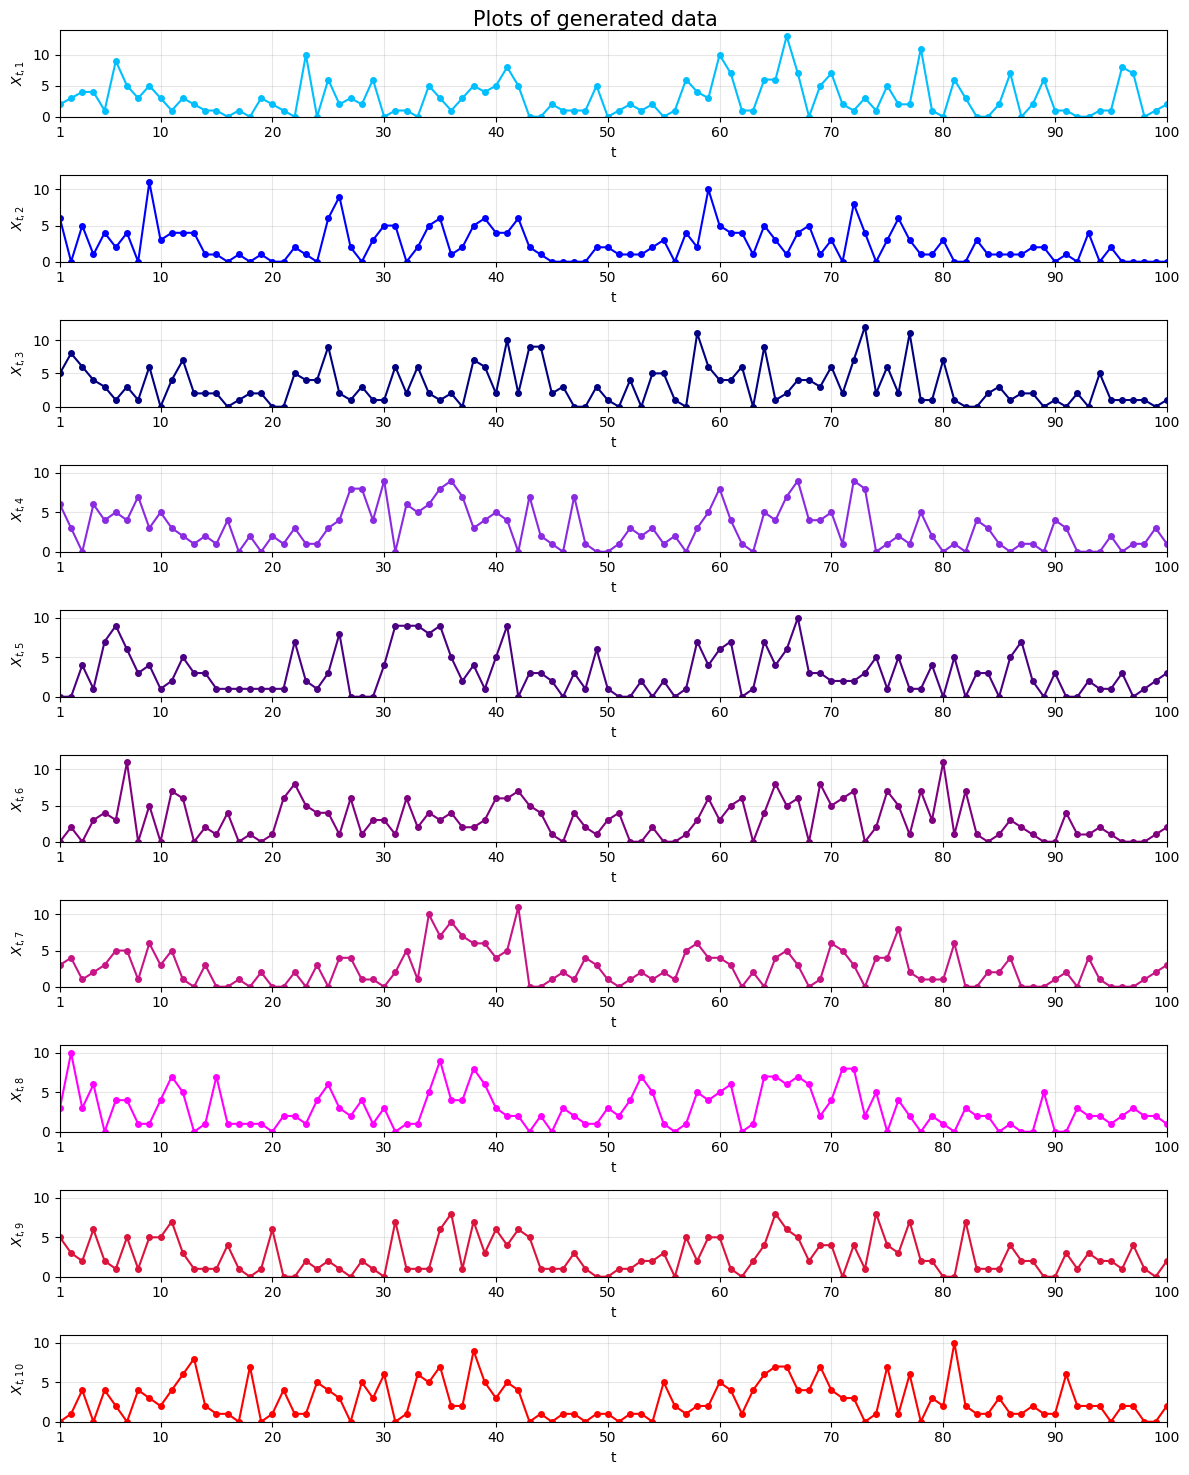

In [ ]:
def plotter(X):
    n = X.shape[1]
    T = np.arange(1, X.shape[0]+1)
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.5*n))
    fig.suptitle("Plots of generated data", fontsize=15)
    
    x_ticks = np.r_[1, np.arange(10, 101, 10)] # makes [1, array([10, 20, ...])] where r_ turns it into [1, 10, 20, ...]
    cmap = ListedColormap([
        'deepskyblue','blue','navy','blueviolet','indigo',
        'purple','mediumvioletred','magenta','crimson','r'
    ])
    colors = cmap.colors
    for i in range(0,n):
        axes[i].plot(T, X[:,i], marker="o", markersize=4, color=colors[i % len(colors)], zorder=2)
        axes[i].set_xlabel("t")
        axes[i].set_xlim(1,100)
        axes[i].set_xticks(x_ticks)
        y_top = max(10, X[:, i].max()) # so we ensure the y ticks has 0, 5, 10 and not just 0, 5
        axes[i].set_ylim(0,y_top+1) # range of y ticks. If we want to have the same range for all plots, change to static values or the highest value in entire dataset
        axes[i].set_ylabel(f"$X_{{t,{i+1}}}$")
        axes[i].yaxis.set_minor_locator(MultipleLocator(5))
        axes[i].grid(which='both',alpha=0.3, zorder=1)

    plt.tight_layout()
    plt.show()

plotter(X)